# Imports and Files

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

df = pd.read_csv('LAP_DATA_ESC2024.CSV', sep=";")
df.reset_index()

df_sd = pd.read_csv('SER5TELE_ESC2024.CSV', sep=",", quotechar='"', on_bad_lines='warn', skipinitialspace=True)
#Remove data before race start
df_sd = df_sd.iloc[23077:]

# Dataprep

In [2]:
df["ms_laptime"] = np.nan
df["ms_racetime"] = np.nan
df_sd["ms_racetime"] = np.nan
df_sd["energy_used"] = np.nan # Wh
df_sd["pv_energy"] = np.nan # Wh

#Race start time including error of RTC
start_time = datetime(2024, 9, 21, 13, 4, 55)

#Calculate lap times and race time in ms
for i, row in df.iterrows():
    minutes = int(row["laptime"].split(":")[0]) * 60 * 1000
    seconds = int(row["laptime"].split(":")[1].split(".")[0]) * 1000
    milliseconds = int(row["laptime"].split(":")[1].split(".")[1])
    df["ms_laptime"][i] = minutes+seconds+milliseconds
    
    hours = int(row["racetime"].split(":")[0]) * 60 * 60 * 1000
    minutes = int(row["racetime"].split(":")[1]) * 60 * 1000
    seconds = int(row["racetime"].split(":")[2].split(".")[0]) * 1000
    milliseconds = int(row["racetime"].split(":")[2].split(".")[1])
    df["ms_racetime"][i] = hours+minutes+seconds+milliseconds

C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\2099003083.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ms_laptime"][i] = minutes+seconds+milliseconds
C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\2099003083.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ms_racetime"][i] = hours+minutes+seconds+milliseconds


In [14]:
#calculate racetime for SD card data
#calculate energy used and pv energy

for i, row in df_sd.iterrows():
    racetime = datetime.strptime(row["DateTimeStamp"], '%Y-%m-%dT%H:%M:%S') - start_time
    df_sd["ms_racetime"][i] = racetime.total_seconds()*1000
    
    if (df_sd["batteryCurrent"][i] < 120 and
            df_sd["batteryCurrent"][i] > -120 and
            df_sd["batteryVoltage"][i] > 0 and
            df_sd["batteryVoltage"][i] < 120):
        
        # 3/3600 due to 3 second sampling rate :/
        E = df_sd["batteryCurrent"][i] * df_sd["batteryVoltage"][i] * (3/3600)
        E -= df_sd["pvCurrent"][i] * df_sd["batteryVoltage"][i] * (3/3600)
        df_sd["energy_used"][i] = E 
        df_sd["pv_energy"][i] = df_sd["pvCurrent"][i] * df_sd["batteryVoltage"][i] * (3/3600)
        

C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\525080978.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sd["ms_racetime"][i] = racetime.total_seconds()*1000
C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\525080978.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sd["energy_used"][i] = E
C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\525080978.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sd["pv_ener

In [4]:
#add lap numbers to SD card data

sd_index = 0
df_sd["lapnumber"] = 0

for i, row in df.iterrows():
    lap_end = row["ms_racetime"]
    
    while df_sd["ms_racetime"].iloc[sd_index] < lap_end:
        df_sd["lapnumber"].iloc[sd_index] = int(row["lapnumber"])
        sd_index += 1

C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\3180875976.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sd["lapnumber"].iloc[sd_index] = int(row["lapnumber"])


In [5]:
#add energy used by lap to race timing data
df_energy_by_lap = df_sd.groupby("lapnumber").sum("energy_used")["energy_used"]
df["energy_used"] = np.nan

for i, row in df.iterrows():
    df["energy_used"][i] = df_energy_by_lap[row["lapnumber"]]

C:\Users\Tobias\AppData\Local\Temp\ipykernel_19860\3182749834.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["energy_used"][i] = df_energy_by_lap[row["lapnumber"]]


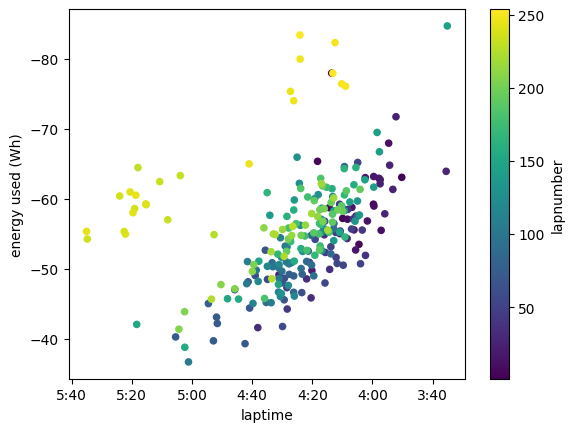

In [6]:
import matplotlib.pyplot as plt

df.query("energy_used < 1000 and ms_laptime < 600000") \
    .plot.scatter(x="ms_laptime", y="energy_used", c="lapnumber", colormap='viridis') \
    .invert_yaxis()


plt.xlabel("laptime")
plt.ylabel("energy used (Wh)")
plt.gca().invert_xaxis()
plt.xticks([220000, 240000, 260000, 280000, 300000, 320000, 340000],["3:40", "4:00", "4:20", "4:40", "5:00", "5:20", "5:40"])
pass

<AxesSubplot: xlabel='ms_racetime', ylabel='ms_laptime'>

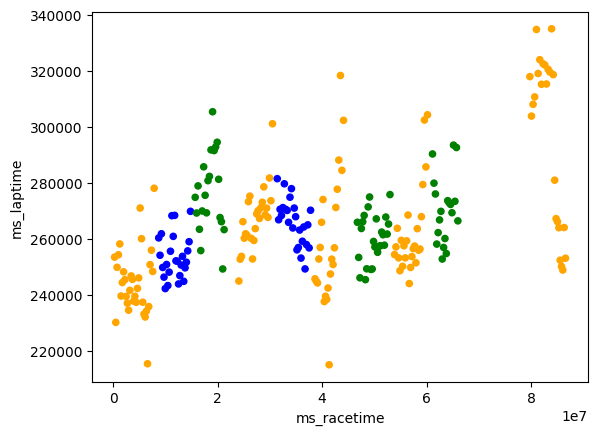

In [12]:
colors = {"Tobias":"orange", "Damian":"blue", "Jonas":"green"}
df['driver_color'] = df['drivername'].map(lambda x: colors[x])

df.query("energy_used < 1000 and ms_laptime < 600000") \
    .plot.scatter(x="ms_racetime", y="ms_laptime", c="driver_color")

<AxesSubplot: xlabel='ms_racetime', ylabel='batteryVoltage'>

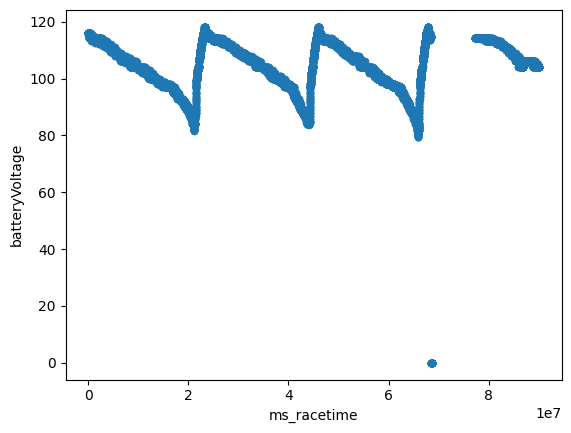

In [236]:
df_sd.query("batteryVoltage < 120") \
    .plot.scatter(x="ms_racetime", y="batteryVoltage")

In [ ]:
#find quickest set of 73 laps in the race
timelist = []

for i, row in df[df["lapnumber"] < 228].iterrows():
    print(str(i) + ": " + str(df[i:i+73]["ms_laptime"].sum()))
    timelist.append(df[i:i+73]["ms_laptime"].sum())
    
    
print(min(timelist))
# its the first 73 laps
# took 11747365ms / 5 Hours 21 Minutes 41 Seconds
# we only had 5h to make 73 laps after charge 3 (in theory)


In [10]:
print(df_sd.query("batteryCurrent < 50")["energy_used"].sum())
print(df.query("ms_laptime < 600000")["energy_used"].mean())
print(df.groupby("drivername")["ms_laptime"].min())

-13631.236205179166
-55.408405852798346
drivername
Damian    242316.0
Jonas     245494.0
Tobias    215109.0
Name: ms_laptime, dtype: float64


In [15]:
df_sd.to_csv("SER5_TELE_ENHANCED.CSV")
df.to_csv("LAP_DATA_ESC2024_ENHANCED.CSV")